<a href="https://colab.research.google.com/github/fahadahmad84-design/Quantum-Computing-Labs/blob/main/Notebooks/Week_02_QC_M34099_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Laboratory : Qubit States, Phase and Measurement Bases


[![View in GitHub](https://img.shields.io/badge/View%20in-GitHub-black?logo=github)](https://github.com/fahadahmad84-design/Quantum-Computing-Labs/blob/main/notebooks/Week_02_QC_M34099_Student.ipyn)


**M34099 Quantum Computing : Level 7 (2026–27)**  
**Problem:** A supplier claims that its one-qubit circuit is a trustworthy quantum random-number generator (QRNG). You will audit the claim using statevectors, the Bloch sphere, two measurement bases, simulation and:if classroom access is ready:real IBM quantum hardware.

## Learning outcomes

By the end of this laboratory, you should be able to:

1. normalise a statevector containing complex amplitudes;
2. distinguish amplitudes, probabilities and relative phase;
3. locate common states on the Bloch sphere;
4. explain why one measurement basis may not identify a state;
5. implement X-basis measurement using a basis-change gate;
6. compare ideal simulation with real-device evidence; and
7. make a justified recommendation about a QRNG claim.

## Working method

For each activity: **Predict → Build → Inspect → Run → Explain**. Complete the simulator work first. Real hardware is optional and must remain disabled until your IBM classroom access is ready.

> **Saving your work:** Select **File → Save a copy in Drive** before editing. Never place an API key or CRN in a visible notebook cell.


## 1. Set up Google Colab

Run the installation cell once. Installation may take a minute. If Colab requests a restart, select **Runtime → Restart session**, then continue from the imports cell.


In [1]:
# Install Qiskit, Aer, IBM Runtime, and circuit drawing support.
%pip install -q "qiskit[visualization]" qiskit-aer qiskit-ibm-runtime pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.3/113.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.

In [2]:
# Numerical calculations and plotting.
import numpy as np
# Import Matplotlib for displaying plots.
import matplotlib.pyplot as plt

# Qiskit circuit, statevector, simulator and visualisation tools.
from qiskit import QuantumCircuit, transpile
# Import the exact statevector representation.
from qiskit.quantum_info import Statevector
# Import the local ideal quantum simulator.
from qiskit_aer import AerSimulator
# Import the Bloch-sphere and histogram plotting functions.
from qiskit.visualization import plot_bloch_multivector, plot_histogram

# Reproducible simulator settings.
SHOTS = 4096
# Set a fixed seed so simulator results are reproducible.
RNG_SEED = 34099
# Create the Aer simulator object.
simulator = AerSimulator()

# Display the current result.
print("Setup complete.")
# Display the current result.
print(f"Shots: {SHOTS}; simulator seed: {RNG_SEED}")


Setup complete.
Shots: 4096; simulator seed: 34099


## 2. Before coding: amplitudes, probabilities and phase

A one-qubit pure state is

$$|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,$$

where $\alpha,\beta\in\mathbb{C}$ and $|\alpha|^2+|\beta|^2=1$. A Z-basis measurement returns 0 with probability $|\alpha|^2$ and 1 with probability $|\beta|^2$.

However, these two probabilities do **not** reveal the relative phase between the amplitudes. For example,

$$|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2},\qquad
|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}$$

have the same Z-basis probabilities but are different:and orthogonal:states.

### Prediction checkpoint

Before running code, record:

- the squared norm of $v=[1,1+i]^T$;
- the Z-basis probabilities after normalisation;
- the Bloch-sphere directions of $|0\rangle,|1\rangle,|+\rangle,|-\rangle,|+i\rangle$; and
- what you expect when $|+\rangle$ and $|-\rangle$ are measured in the X basis.


## 3. Task 1 : Normalise a complex statevector

For $v=[1,1+i]^T$, calculate $\|v\|^2=\langle v|v\rangle$, form $|\psi\rangle=v/\|v\|$, and calculate the two Z-basis probabilities.

First complete the calculation on your worksheet. Then use the code as an independent check.


In [3]:
# Create the unnormalised complex statevector.
v = np.array([1, 1 + 1j], dtype=complex)

# <v|v> = |1|^2 + |1+i|^2 = 1 + 2 = 3.
norm_squared = np.vdot(v, v).real

# Divide by sqrt(3), not by 3.
psi = v / np.sqrt(norm_squared)

# Born rule: square the magnitude of each amplitude.
probabilities = np.abs(psi) ** 2

# Display the current result.
print("Squared norm:", norm_squared)
# Display the current result.
print("Normalised state:", psi)
# Display the current result.
print("Z-basis probabilities:", probabilities)
# Display the current result.
print("Probability sum:", probabilities.sum())

# Verify that the calculated result matches the expected value.
assert np.isclose(norm_squared, 3.0)
# Verify that the calculated result matches the expected value.
assert np.allclose(probabilities, [1/3, 2/3])
# Verify that the calculated result matches the expected value.
assert np.isclose(probabilities.sum(), 1.0)


Squared norm: 3.0
Normalised state: [0.57735027+0.j         0.57735027+0.57735027j]
Z-basis probabilities: [0.33333333 0.66666667]
Probability sum: 1.0000000000000002


### Explain

In your own words, answer:

1. Why is `np.vdot(v, v)` preferable to `np.dot(v, v)` for a complex statevector?
2. Why do we divide by $\sqrt{\langle v|v\rangle}$ rather than by $\langle v|v\rangle$?
3. Which basis outcome is more likely, and why?


## 4. Task 2 : Visualise relative phase on the Bloch sphere

Construct five standard states. Predict their directions before plotting:

| State | Expected direction |
|---|---|
| $|0\rangle$ | ? |
| $|1\rangle$ | ? |
| $|+\rangle$ | ? |
| $|-\rangle$ | ? |
| $|+i\rangle$ | ? |

The phase difference changes the state even when Z-basis probabilities remain unchanged.


|0> [1.+0.j 0.+0.j]


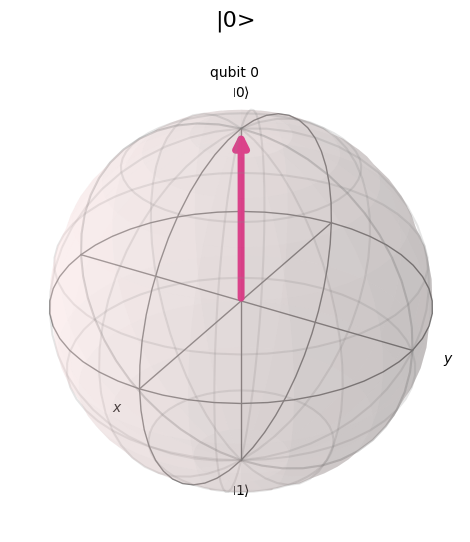

|1> [0.+0.j 1.+0.j]


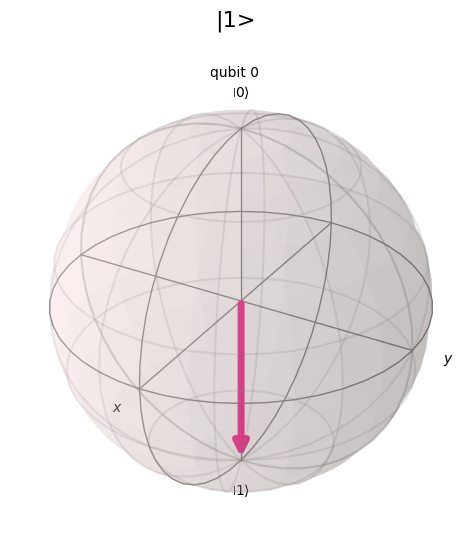

|+> [0.70710678+0.j 0.70710678+0.j]


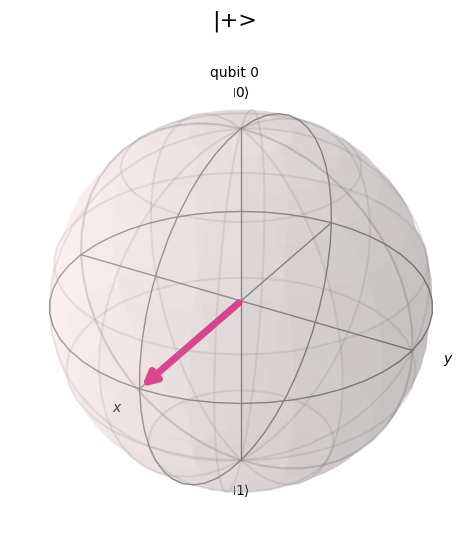

|-> [ 0.70710678+0.j -0.70710678+0.j]


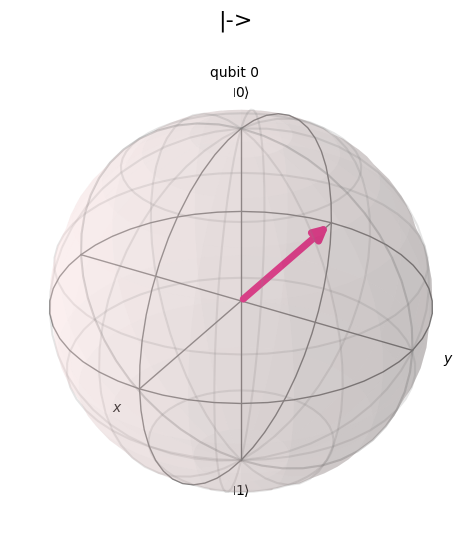

|+i> [0.70710678+0.j         0.        +0.70710678j]


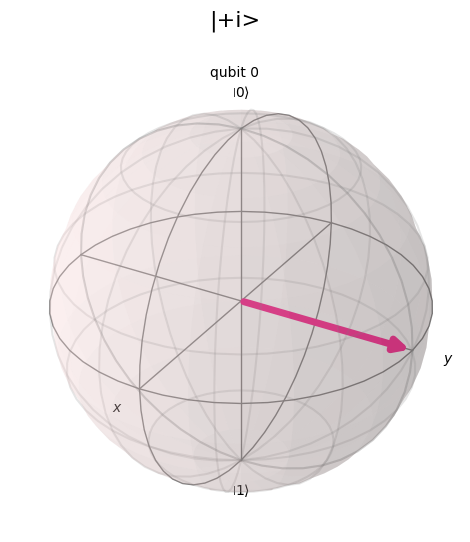

In [4]:
# Create the computational basis state zero.
zero = Statevector.from_label("0")
# Create the computational basis state one.
one = Statevector.from_label("1")
# Create the equal positive superposition state.
plus = Statevector(np.array([1, 1], dtype=complex) / np.sqrt(2))
# Create the equal negative superposition state.
minus = Statevector(np.array([1, -1], dtype=complex) / np.sqrt(2))
# Create the state with a relative phase of positive i.
plus_i = Statevector(np.array([1, 1j], dtype=complex) / np.sqrt(2))

# Store the states with readable labels.
states = {
    "|0>": zero,
    "|1>": one,
    "|+>": plus,
    "|->": minus,
    "|+i>": plus_i,
}

# Visit each labelled state in the collection.
for name, state in states.items():
    # Display the current result.
    print(name, state.data)
    # Display the generated circuit or visualisation.
    display(plot_bloch_multivector(state, title=name))


## 5. Task 3 : Same Z-basis data, different states

Compare $|+\rangle$ and $|-\rangle$ using exact statevector calculations. Determine:

- their Z-basis probability distributions; and
- their inner product $\langle+|-\rangle$.

### Predict

Will the Z-basis probabilities identify which state was prepared? Does an inner product of zero mean that the two states are identical or orthogonal?


In [5]:
# Calculate the exact Z-basis probabilities for the plus state.
z_plus = plus.probabilities_dict()
# Calculate the exact Z-basis probabilities for the minus state.
z_minus = minus.probabilities_dict()
# Calculate the inner product of the two states.
overlap = plus.inner(minus)

# Display the current result.
print("Z probabilities for |+>:", z_plus)
# Display the current result.
print("Z probabilities for |->:", z_minus)
# Display the current result.
print("<+|-> =", overlap)

# Verify that the calculated result matches the expected value.
assert np.allclose(plus.probabilities(), minus.probabilities())
# Verify that the calculated result matches the expected value.
assert np.isclose(overlap, 0.0)

# Display the current result.
print("Conclusion: Z probabilities are identical, but the states are orthogonal.")


Z probabilities for |+>: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}
Z probabilities for |->: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}
<+|-> = 0j
Conclusion: Z probabilities are identical, but the states are orthogonal.


## 6. Task 4 : Reveal the difference by changing basis

Qiskit measures computationally in the Z basis. To measure in the X basis, apply a Hadamard gate immediately before measurement:

$$\text{X-basis measurement}=H+\text{Z-basis measurement}.$$

Build one circuit that prepares $|+\rangle$ and another that prepares $|-\rangle$. Measure each in X. Use the same shots and random seed so that the experiment is reproducible.


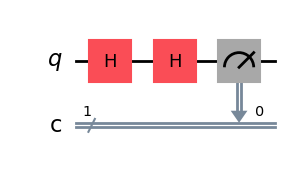

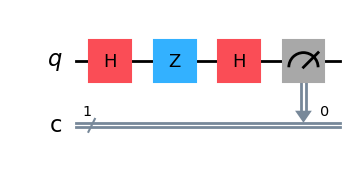

|+> measured in X: {'0': 4096}
|-> measured in X: {'1': 4096}


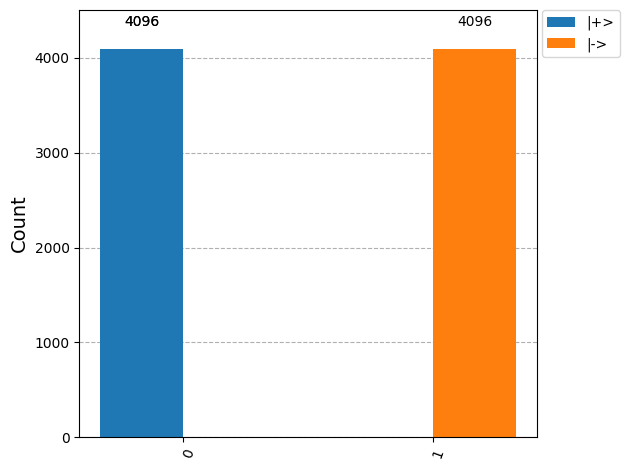

In [6]:
# Define a reusable experiment for X-basis measurement.
def x_basis_experiment(prepare_minus=False):
    # Create a one-qubit circuit with one classical output bit.
    qc = QuantumCircuit(1, 1)

    # H|0> = |+>.
    qc.h(0)

    # Z|+> = |->.
    if prepare_minus:
        # Apply a Z gate to change the relative phase.
        qc.z(0)

    # H maps the X eigenstates to Z eigenstates before measurement.
    qc.h(0)
    # Measure the qubit into the classical bit.
    qc.measure(0, 0)

    # Transpile the circuit for the selected simulator.
    compiled = transpile(qc, simulator, seed_transpiler=RNG_SEED)
    # Run the circuit with reproducible simulator settings.
    result = simulator.run(
        compiled,
        shots=SHOTS,
        seed_simulator=RNG_SEED,
    ).result()
    # Return the circuit and its measurement counts.
    return qc, result.get_counts()

# Run the X-basis experiment for the plus state.
plus_circuit, plus_x_counts = x_basis_experiment(False)
# Run the X-basis experiment for the minus state.
minus_circuit, minus_x_counts = x_basis_experiment(True)

# Display the generated circuit or visualisation.
display(plus_circuit.draw("mpl"))
# Display the generated circuit or visualisation.
display(minus_circuit.draw("mpl"))
# Display the current result.
print("|+> measured in X:", plus_x_counts)
# Display the current result.
print("|-> measured in X:", minus_x_counts)
# Display the generated circuit or visualisation.
display(plot_histogram([plus_x_counts, minus_x_counts], legend=["|+>", "|->"]))

# Verify that the calculated result matches the expected value.
assert plus_x_counts == {"0": SHOTS}
# Verify that the calculated result matches the expected value.
assert minus_x_counts == {"1": SHOTS}


## 7. Task 5 : PBL audit of the QRNG claim

The supplier's circuit applies `H` to $|0\rangle$ and then measures in Z. Audit it in both Z and X bases.

Collect:

- counts and relative frequencies;
- absolute deviation of the Z-basis frequency from 0.5;
- the X-basis signature; and
- a clear statement of what an **ideal simulator can and cannot establish**.

Remember: a balanced sample is evidence about this run. It is not, by itself, proof of independence, unpredictability, device security or absence of bias.


Z-basis counts: {'1': 2034, '0': 2062}
Z relative frequencies: P(0)=0.5034, P(1)=0.4966
Absolute deviation of P(0) from 0.5: 0.0034
X-basis counts: {'0': 4096}


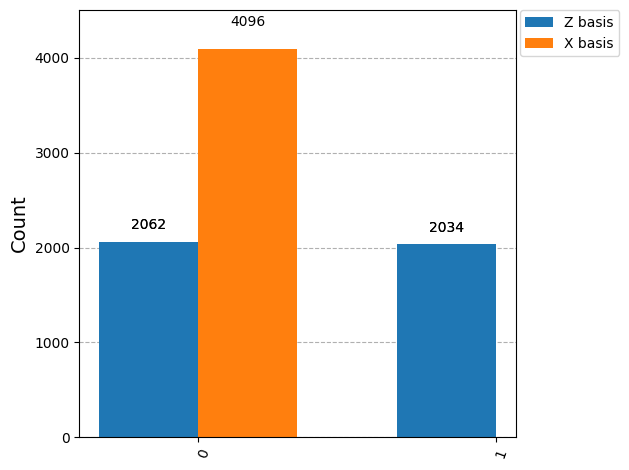

In [7]:
# Define a reusable function for measuring the circuit in Z or X.
def run_qrng(measure_basis="Z"):
    # Create a one-qubit circuit with one classical output bit.
    qc = QuantumCircuit(1, 1)
    # Apply a Hadamard gate to the qubit.
    qc.h(0)  # Prepare |+>.

    # Check whether an X-basis measurement is requested.
    if measure_basis.upper() == "X":
        # Apply a Hadamard gate to the qubit.
        qc.h(0)  # X-to-Z basis change.
    # Reject a measurement-basis label other than Z or X.
    elif measure_basis.upper() != "Z":
        # Raise a clear error for an unsupported basis label.
        raise ValueError("measure_basis must be 'Z' or 'X'.")

    # Measure the qubit into the classical bit.
    qc.measure(0, 0)
    # Transpile the circuit for the selected simulator.
    compiled = transpile(qc, simulator, seed_transpiler=RNG_SEED)
    # Run the compiled circuit and return its measurement counts.
    return simulator.run(
        compiled,
        shots=SHOTS,
        seed_simulator=RNG_SEED,
    ).result().get_counts()

# Run the circuit using Z-basis measurement.
z_counts = run_qrng("Z")
# Run the circuit using X-basis measurement.
x_counts = run_qrng("X")

# Calculate the observed Z-basis frequency of zero.
p0_z = z_counts.get("0", 0) / SHOTS
# Calculate the observed Z-basis frequency of one.
p1_z = z_counts.get("1", 0) / SHOTS
# Calculate the absolute deviation from an ideal probability of one half.
deviation = abs(p0_z - 0.5)

# Display the current result.
print("Z-basis counts:", z_counts)
# Display the current result.
print(f"Z relative frequencies: P(0)={p0_z:.4f}, P(1)={p1_z:.4f}")
# Display the current result.
print(f"Absolute deviation of P(0) from 0.5: {deviation:.4f}")
# Display the current result.
print("X-basis counts:", x_counts)
# Display the generated circuit or visualisation.
display(plot_histogram([z_counts, x_counts], legend=["Z basis", "X basis"]))

# Verify that the calculated result matches the expected value.
assert sum(z_counts.values()) == SHOTS
# Verify that the calculated result matches the expected value.
assert x_counts == {"0": SHOTS}


## 8. Optional extension : Run the audit circuit on IBM hardware

Complete this section only after your tutor confirms that IBM Quantum Classroom access is ready.

- Keep `RUN_ON_REAL_HARDWARE = False` while waiting for access.
- Use your **own** IBM Cloud API key.
- Use the classroom CRN supplied through Moodle.
- Hidden prompts prevent the values from appearing on screen.
- Never save credentials in this notebook, Google Drive, Moodle or GitHub.

The authentication cell requests the two required items once per Colab session. Rerunning it after a runtime restart will request them again.


In [8]:
# Safety switch: simulator work does not require IBM credentials.
RUN_ON_REAL_HARDWARE = False

# Display the current result.
print("Real-hardware execution enabled:", RUN_ON_REAL_HARDWARE)


Real-hardware execution enabled: False


In [9]:
# Check whether real-hardware execution is enabled.
if RUN_ON_REAL_HARDWARE:
    # Connect only once during the current Colab session.
    if "ibm_service" not in globals():
        # Import secure hidden-input support.
        from getpass import getpass
        # Import the IBM Quantum Runtime service.
        from qiskit_ibm_runtime import QiskitRuntimeService

        # Request the personal IBM Cloud API key securely.
        ibm_api_key = getpass("Enter your personal IBM Cloud API key: ")
        # Request the classroom instance CRN securely.
        classroom_crn = getpass("Enter the classroom instance CRN: ")

        # Connect to the assigned IBM Quantum classroom instance.
        ibm_service = QiskitRuntimeService(
            channel="ibm_quantum_platform",
            token=ibm_api_key,
            instance=classroom_crn,
        )

        # Remove plaintext variables after the service object is created.
        del ibm_api_key, classroom_crn
        # Display the current result.
        print("Connected to the IBM Quantum classroom instance.")
    # Handle the alternative condition.
    else:
        # Display the current result.
        print("Already connected in this Colab session.")
# Handle the alternative condition.
else:
    # Display the current result.
    print("Hardware section skipped. Set RUN_ON_REAL_HARDWARE = True when access is ready.")


Hardware section skipped. Set RUN_ON_REAL_HARDWARE = True when access is ready.


In [10]:
# Check whether real-hardware execution is enabled.
if RUN_ON_REAL_HARDWARE:
    # Import the device-aware circuit pass manager.
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    # Import the IBM Runtime Sampler version 2 interface.
    from qiskit_ibm_runtime import SamplerV2

    # Set a modest number of hardware shots to limit queue use.
    HARDWARE_SHOTS = 1024
    # Select an operational non-simulator backend with a short queue.
    backend = ibm_service.least_busy(operational=True, simulator=False)
    # Display the current result.
    print("Selected backend:", backend.name)

    # Create the hardware circuit with one qubit and one classical bit.
    hardware_circuit = QuantumCircuit(1, 1)
    # Apply Hadamard to prepare the plus state.
    hardware_circuit.h(0)
    # Measure the hardware qubit in the Z basis.
    hardware_circuit.measure(0, 0)

    # Create a pass manager matched to the selected device.
    pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)
    # Translate the circuit into instructions supported by the device.
    isa_circuit = pass_manager.run(hardware_circuit)

    # Create a Runtime Sampler for the selected backend.
    sampler = SamplerV2(mode=backend)
    # Submit the circuit to the hardware queue.
    hardware_job = sampler.run([isa_circuit], shots=HARDWARE_SHOTS)
    # Display the current result.
    print("Job ID:", hardware_job.job_id())

    # Wait for the hardware job and obtain its result.
    hardware_result = hardware_job.result()
    # Extract counts from the circuit classical register.
    hardware_counts = hardware_result[0].data.c.get_counts()
    # Display the current result.
    print("Hardware counts:", hardware_counts)
    # Display the generated circuit or visualisation.
    display(plot_histogram(hardware_counts, title=f"IBM hardware: {backend.name}"))
# Handle the alternative condition.
else:
    # Display the current result.
    print("No hardware job submitted.")


No hardware job submitted.


### Hardware comparison

If you completed the hardware run, calculate the hardware relative frequencies and compare them with your seeded ideal-simulator results.

```python
if RUN_ON_REAL_HARDWARE:
    p0_hardware = hardware_counts.get("0", 0) / HARDWARE_SHOTS
    p1_hardware = hardware_counts.get("1", 0) / HARDWARE_SHOTS
    print(f"Hardware P(0)={p0_hardware:.4f}; P(1)={p1_hardware:.4f}")
```

Discuss whether any difference could arise from finite sampling, device noise, readout error, drift or calibration. A single run is insufficient to certify a production QRNG.


## 9. Audit record and recommendation

Complete the accompanying PBL worksheet. Your evidence statement should include:

1. the prepared state and its normalisation;
2. Z- and X-basis results, with shots and simulator seed;
3. why Z-basis data alone cannot distinguish $|+
angle$ from $|-
angle$;
4. simulator–hardware differences, if hardware was used;
5. limitations of the evidence; and
6. one recommendation: **accept**, **accept conditionally**, or **reject**, supported by evidence.

### Exit questions

1. What physical information is absent from Z-basis probabilities?
2. Why does a Hadamard gate enable X-basis measurement?
3. Why is a seeded ideal simulation reproducible but not evidence of physical randomness?
4. What additional tests would you require before certifying a real QRNG?


## References

- IBM Quantum Documentation, *Statevector*: https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.quantum_info.Statevector
- IBM Quantum Documentation, *Visualise quantum states*: https://quantum.cloud.ibm.com/docs/guides/plot-quantum-states
- IBM Quantum Documentation, *Run jobs with Qiskit Runtime*: https://quantum.cloud.ibm.com/docs/guides/run-jobs
- Qiskit Aer documentation: https://qiskit.github.io/qiskit-aer/

Accessed 28 September 2026.
